# НИС «Основы анализа данных в Python»

*Алла Тамбовцева*

## Практикум 12: характеристики распределения

Необходимые импорты:

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import skew, kurtosis

Глобальные настройки для графиков (вспомните, что это и подумайте, зачем эти настройки делать глобальными):

In [2]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

> Здесь мы настраиваем разрешение изображений с графиками, делаем его равным 300 точек на дюйм. Первая строка с `figure.dpi` изменяет разрешение у графиков, отображаемых в Jupyter (объекты типа `figure`), а строка с `savefig.dpi` – разрешение у графиков, экспортируемых в файл через метод `savefig`. Фиксируя настройки глобально, мы гарантируем, что они будут применены ко всем графикам в этом файле, созданным с помощью `matplotlib` (в том числе внутри `pandas`) и его надстроек вроде библиотеки `seaborn`. Название `rcParams` расшифровывается как *runtime configuration parameters* и представляет собой объект, похожий на словарь с огромным перечнем всех настроек. В данном случае мы изменяем записи с ключами `figure.dpi` и `savefig.dpi`, парамеры класса [figure](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure).

### Задача 1

Создан массив `x`, хранящий некоторую выборку:

In [3]:
x = np.array([4, 6, 20, 45, 21, 10, 2, 0, -12, 20, 60] * 5)
print(x)

[  4   6  20  45  21  10   2   0 -12  20  60   4   6  20  45  21  10   2
   0 -12  20  60   4   6  20  45  21  10   2   0 -12  20  60   4   6  20
  45  21  10   2   0 -12  20  60   4   6  20  45  21  10   2   0 -12  20
  60]


Ниже приведён фрагмент кода, который вычисляет среднее и медиану, а также частоты для значений:

In [4]:
print("Среднее:", np.mean(x))
print("Медиана:", np.median(x))

unique_values, counts = np.unique(x, return_counts = True)

print(unique_values)
print(counts)

Среднее: 16.0
Медиана: 10.0
[-12   0   2   4   6  10  20  21  45  60]
[ 5  5  5  5  5  5 10  5  5  5]


Напишите код, который выведет пары *значение-частота*, упорядочив их от самого частого к самому редкому.

Пример вывода:

    Частоты:
    (-20, 10)
    (-60, 5)
    (-45, 5)
    (-21, 5)
    ...

In [5]:
# через zip() формируем пары значение-частота
# через sorted() выполняем сортировку:
# в key указываем правило сортировки через lambda-функцию, 
# сортировать нужно по второму элементу–частоте,
# в reverse «включаем» убывание

pairs = sorted(zip(unique_values, counts), 
              key = lambda x: x[1], 
              reverse = True)

# распаковываем список через *
# и выводим каждую пару с новой строки

print(*pairs, sep = "\n")

(20, 10)
(-12, 5)
(0, 5)
(2, 5)
(4, 5)
(6, 5)
(10, 5)
(21, 5)
(45, 5)
(60, 5)


**Дополнение.** Если у вас новая версия `numpy` с добавленными объектами *numpy scalars*, чтобы название `np.int64` не выводилось на экран, придется обратиться к циклу и разобрать пары на части. 

In [6]:
for pair in pairs:
    print(pair[0], pair[1])

20 10
-12 5
0 5
2 5
4 5
6 5
10 5
21 5
45 5
60 5


Особенность этих скаляров (назвали их по аналогии с линейной алгеброй, раз одномерный массив – это вектор, то нульмерный массив, одно число – это скаляр) в том, что при выводе на экран через `print()` название типа убирается только если скаляр не включен в другие структуры. То есть код `print(np.int64(7))` выведет просто `7`, а код `print([np.int64(7), np.int64(7)])` – строку `[np.int64(7), np.int64(7)]`.

### Задача 2

Ниже приведён код, который строит для массива `x` гистограмму, ящик с усами и сохраняет их в файлы: 

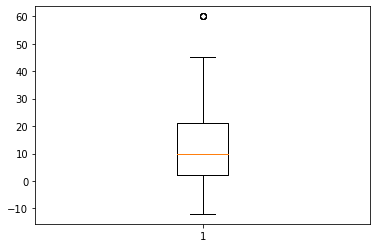

In [7]:
# строим гистограмму для x,
# экспортируем картинку в файл
# очищаем оси для графика через .clf()

plt.hist(x, color = "grey", edgecolor = "w");
plt.savefig("hist01.png")
plt.clf()


# строим ящик с усами для x,
# экспортируем картинку в файл
plt.boxplot(x);
plt.savefig("box01.png")

**Важно.** если в коде выше убрать строку `plt.clf()` для очищения предыдущего графика, оба графика построятся в одних осях, а так как гистограмма и ящик с усами – принципиально разные графики, «поедет» масштаб:

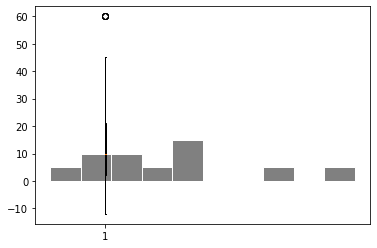

In [8]:
plt.hist(x, color = "grey", edgecolor = "w");
plt.savefig("hist01.png")

plt.boxplot(x);
plt.savefig("box01.png")

Напишите функцию `describe()`, которая принимает на вход выборку (массив), название выборки (строка) и:

* выводит на экран среднее, медиану, частоты значений в виде пар (как в задаче №1);
* сохраняет в файл `hist_{название выборки}.png` картинку с гистограммой, а в файл `box_{название выборки}.png` – картинку с ящиком с усами.

In [9]:
def describe(x, name):
    print("Среднее:", np.mean(x))
    print("Медиана:", np.median(x))
    unique_values, counts = np.unique(x, 
                                      return_counts = True)
    pairs = sorted(zip(unique_values, counts), 
                   key = lambda x: x[1], 
                   reverse = True)
    print(*pairs, sep = "\n")
    
    plt.hist(x, color = "grey", edgecolor = "w");
    plt.savefig(f"hist_{name}.png")
    plt.clf()
    
    # важно: тут тоже .clf() в конце, 
    # так как функцию будем запускать много раз,
    # иначе предыдущий ящик будет оставаться
    
    plt.boxplot(x);
    plt.savefig(f"box_{name}.png")
    plt.clf()

### Задача 3

Примените функцию `describe()` к массивам `y` и `z` ниже и сравните распределения. 

In [10]:
y = -x
z = x ** 2

describe(y, "02")
describe(z, "03")

Среднее: -16.0
Медиана: -10.0
(-20, 10)
(-60, 5)
(-45, 5)
(-21, 5)
(-10, 5)
(-6, 5)
(-4, 5)
(-2, 5)
(0, 5)
(12, 5)
Среднее: 651.4545454545455
Медиана: 144.0
(400, 10)
(0, 5)
(4, 5)
(16, 5)
(36, 5)
(100, 5)
(144, 5)
(441, 5)
(2025, 5)
(3600, 5)


<Figure size 432x288 with 0 Axes>

>Подробно разбирали на занятии – это распределения из квиза №6. Кратко:
* распределение `x` – скошено вправо, есть потенциальный выброс справа, недалеко от основной массы точек; 
* распределение `y` – скошено влево, есть потенциальный выброс слева, недалеко от основной массы точек; 
* распределение `z` – сильно скошено вправо, есть два явных выброса, удаленных друг от друга и от основной массы точек.

### Задача 4

Объясните, что делает код ниже. Примените к массиву `v` функцию `describe()` и изучите полученные результаты.

In [11]:
v = np.log(np.abs(x))
v = v[v != -np.inf]

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log
  """Entry point for launching an IPython kernel.


> Код создает новый массив `v`, состоящий из натуральных логарифмов значений массива `x`, взятых модулю (абсолютные значения). Взятие модуля через `np.abs()` избавляет нас от отрицательных значений – логарифма от отрицательных значений не существует. В массиве `x` также присутствовали нули – формально, логарифм от 0 равен $-\infty$. Поэтому на месте нулей появились значения специального типа `-np.inf`. Чтобы от них избавиться, была выполнена фильтрация через `v != -np.inf`.

In [12]:
describe(v, "04")

Среднее: 2.5595686790513765
Медиана: 2.7403194616709956
(2.995732273553991, 10)
(0.6931471805599453, 5)
(1.3862943611198906, 5)
(1.791759469228055, 5)
(2.302585092994046, 5)
(2.4849066497880004, 5)
(3.044522437723423, 5)
(3.8066624897703196, 5)
(4.0943445622221, 5)


<Figure size 432x288 with 0 Axes>

> Распределение `v` совсем немного скошено влево (см экспортированную гистограмму `hist_04.png`). Если «убрать» пик, получаемый за счет самого высокого столбца, распределение будет равномерным – все столбцы одинаковой высоты. Этот пример иллюстрирует полезность логарифмирования – часто сильно скошенные данные логарифмируют, чтобы уменьшить скошенность. Однако на практике обходиться с выборками надо более аккуратно – в случае наличия неположительных значений модуль брать нельзя, это изменит природу данных. Вместо этого нужно вычислять логарифмы не для исходного массива `x`, а для массива `x + c`, где `c` – некоторое число, которое обеспечивает одновременный сдвиг всех значений в положительную часть числовой оси.

### Задача 5

В самом начале файла мы импортировали функции `skew()` и `kurtosis()` для вычисления коэффициента скошенности (*skewness*) и эксцесса (*kurtosis*). Используя эти функции, вычислите эти характеристики для распределений выборок `x`, `y`, `z`, `v`. Проинтерпретируйте полученные результаты.

In [13]:
print(skew(x))
print(skew(y))
print(skew(z))
print(skew(v))

0.9027300095054113
-0.9027300095054113
1.913215838702729
-0.27325402387420694


*Для наглядности добавлен блок кода, отрисовывающий четыре гистограммы рядом:*

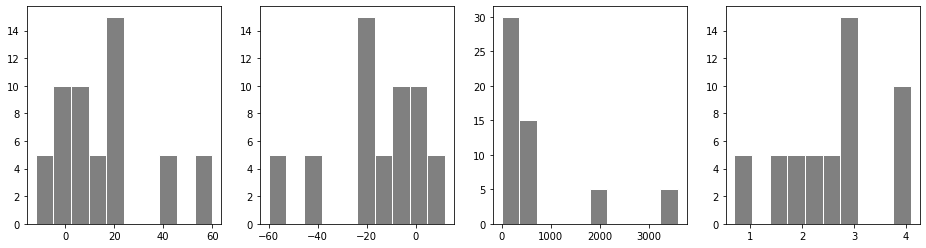

In [14]:
fig, axes = plt.subplots(1, 4, figsize = (16, 4))
axes[0].hist(x, color = "grey", edgecolor = "w");
axes[1].hist(y, color = "grey", edgecolor = "w");
axes[2].hist(z, color = "grey", edgecolor = "w");
axes[3].hist(v, color = "grey", edgecolor = "w");

> Отрицальные значения коэффициента скошенности или асимметрии (*skewness*) соответствуют скошенности влево, а положительные – скошенности вправо. Значения, близкие к 1 по модулю говорят о выраженной скошенности, а близкие по модулю к 2 – о сильной скошенности. Здесь:
* сильная скошенность вправо наблюдается у третьего распределения `z` (значение 1.91) – это распределение с длинным правым «хвостом», содержащим выбросы;
* слабая скошенность влево наблюдается у четвертого распределения `v` (значение -0.27) – это распределение больше остальных похожее на равномерное;
* средняя скошенность наблюдается у первых двух распределений `x` и `y` (значения 0.9 и -0.9), так как `y = -x`, логично, что получились значения, одинаковые по модулю, просто первое скошено вправо, а второе – влево).

In [15]:
print(kurtosis(x))
print(kurtosis(y))
print(kurtosis(z))
print(kurtosis(v))

0.027015140705509477
0.027015140705509477
2.254582497954492
-0.7735946163091181


> Коэффициент эксцесса показывает выраженность пика у распределения. Если у распределения есть острый пик, значения коэффициента положительны, если распредление «плоское» – отрицательны. В первых двух случаях острого пика нет (и значения эксцесса лежат около нуля) – самый высокий столбец несильно отличается от остальных по высоте. У третьего распределения есть ярко выраженный пик (значение больше 2) – он образуется за счет скошенности и нехарактерных значений справа. Четвертое распределение, несмотря на наличие самого высокого столбца, похоже на равномерное, а у равномерных распределений коэффициент эксцесса меньше 0.

### Задача 6

Ниже приведён код для генерации случайной выборки объёма 1600 из стандартного нормального распределения: 

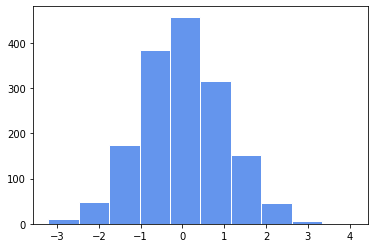

In [16]:
normal_data = np.random.normal(0, 1, 1600)
plt.hist(normal_data, 
         color = "cornflowerblue", 
         edgecolor = "w");

Вычислите для данной выборки коэффициент скошенности и эксцесса. Проинтерпретируйте полученные результаты.

In [17]:
print(skew(normal_data))
print(kurtosis(normal_data))

0.08747387287406924
0.1673457333668158


> Теоретически, у стандартного нормального распределения значения коэффициента скошенности и коэффициента эксцесса равны 0. Но так как здсь мы работаем не с теоретической случайной величиной, а со случайной выборкой, чей объем ограничен, мы получаем значение близкие к нулю, но не нулевые.